In [1]:
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau
from google.colab import files

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
tf.__version__

'2.19.0'

In [3]:
!curl -L -o garbage-classification-v2.zip\
  "https://www.kaggle.com/api/v1/datasets/download/sumn2u/garbage-classification-v2"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1169M  100 1169M    0     0  18.2M      0  0:01:04  0:01:04 --:--:-- 17.6M


In [4]:
!unzip garbage-classification-v2.zip

Streaming output truncated to the last 5000 lines.
  inflating: standardized_384/paper/paper_1193.jpg  
  inflating: standardized_384/paper/paper_1194.jpg  
  inflating: standardized_384/paper/paper_1195.jpg  
  inflating: standardized_384/paper/paper_1196.jpg  
  inflating: standardized_384/paper/paper_1197.jpg  
  inflating: standardized_384/paper/paper_1198.jpg  
  inflating: standardized_384/paper/paper_1199.jpg  
  inflating: standardized_384/paper/paper_12.jpg  
  inflating: standardized_384/paper/paper_120.jpg  
  inflating: standardized_384/paper/paper_1200.jpg  
  inflating: standardized_384/paper/paper_1201.jpg  
  inflating: standardized_384/paper/paper_1202.jpg  
  inflating: standardized_384/paper/paper_1203.jpg  
  inflating: standardized_384/paper/paper_1204.jpg  
  inflating: standardized_384/paper/paper_1205.jpg  
  inflating: standardized_384/paper/paper_1206.jpg  
  inflating: standardized_384/paper/paper_1207.jpg  
  inflating: standardized_384/paper/paper_1208.jpg 

In [5]:
!ls

garbage-classification-v2.zip  sample_data	 standardized_384
original		       standardized_256


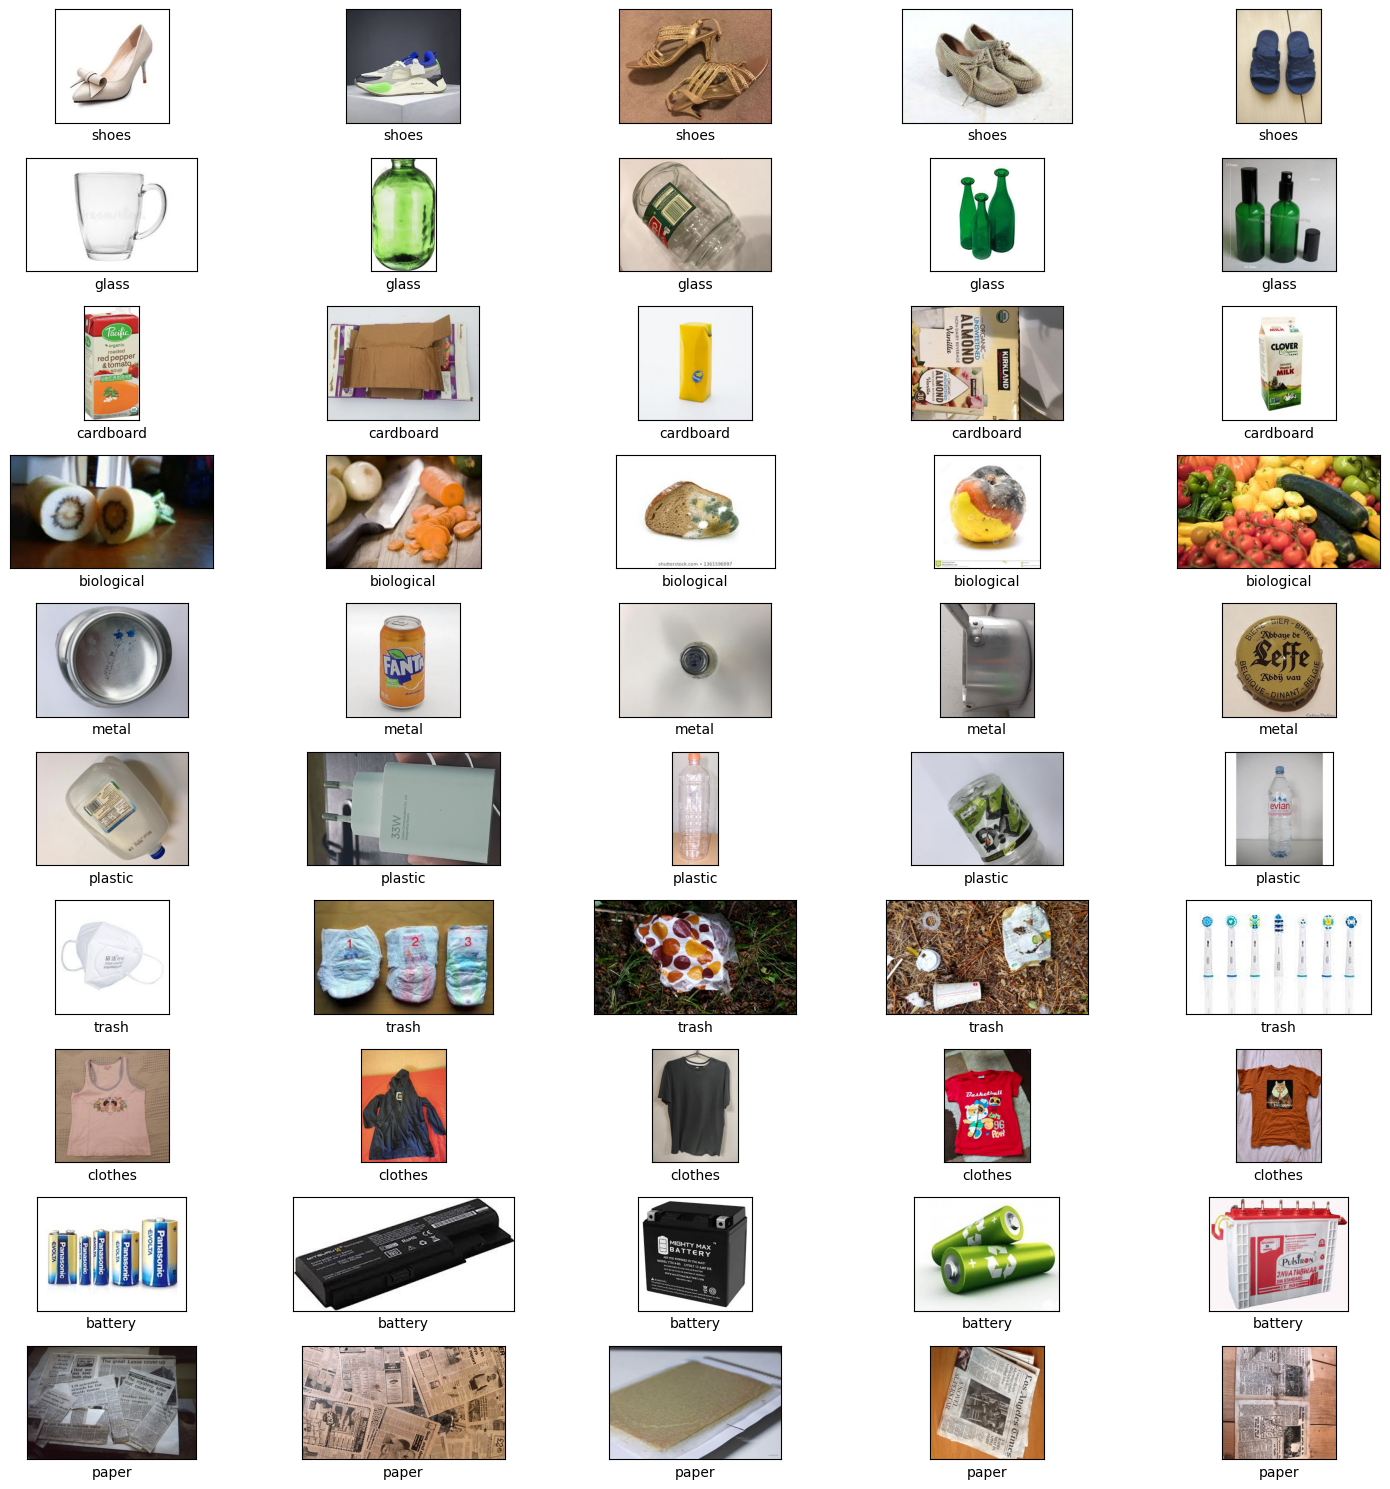

In [6]:
# Membuat subplot daftar file gambar per kelas sampah
garbage_img = {}
path = "original"

for class_folder in os.listdir(path):
    garbage_img[class_folder] = os.listdir(os.path.join(path, class_folder))

fig, axs = plt.subplots(len(garbage_img), 5, figsize=(15, 15))

for i, class_name in enumerate(garbage_img):
    images = np.random.choice(garbage_img[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path, class_name, image_name)
        img = Image.open(img_path)
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

plt.tight_layout()
plt.show()

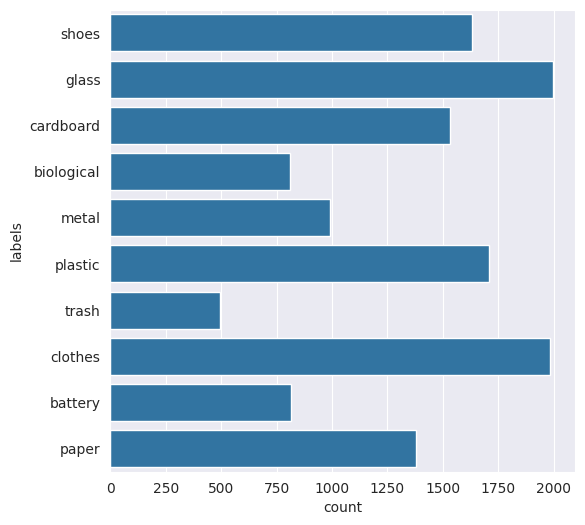

In [7]:
# Dataset original untuk analisis distribusi
garbage_path = "original"

file_name = []
labels = []
full_path = []

# Mengambil filename, path lengkap dan label kelas
for path, subdirs, files in os.walk(garbage_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(os.path.basename(path))
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})

# Plot distribusi jumlah gambar per kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [8]:
def get_image_resolution(filepath):
    with Image.open(filepath) as img:
        return img.size

dataset_path = "original"

data = []

for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            file_path = os.path.join(root, file)
            label = os.path.basename(os.path.dirname(file_path))  # <-- ini
            data.append({
                'filename': file,
                'filepath': file_path,
                'label': label
            })

dataset_df = pd.DataFrame(data)

# Ekstrak resolusi dan aspect ratio
dataset_df['resolution'] = dataset_df['filepath'].apply(get_image_resolution)
dataset_df[['width', 'height']] = pd.DataFrame(dataset_df['resolution'].tolist(), index=dataset_df.index)

dataset_df['aspect_ratio'] = dataset_df['width'] / dataset_df['height']

dataset_df.head()

,filename,filepath,label,resolution,width,height,aspect_ratio
0,shoes_1536.jpg,original/shoes/shoes_1536.jpg,shoes,"(225, 225)",225,225,1.000000
1,shoes_1109.jpg,original/shoes/shoes_1109.jpg,shoes,"(225, 225)",225,225,1.000000
2,shoes_1447.jpg,original/shoes/shoes_1447.jpg,shoes,"(400, 587)",400,587,0.681431
3,shoes_773.jpg,original/shoes/shoes_773.jpg,shoes,"(400, 533)",400,533,0.750469
4,shoes_87.jpg,original/shoes/shoes_87.jpg,shoes,"(400, 533)",400,533,0.750469


In [9]:
dataset_df['resolution'].value_counts()

,count
resolution,
"(512, 384)",2279
"(225, 225)",1483
"(400, 533)",1070
"(400, 534)",522
"(275, 183)",494
...,...
"(1067, 894)",1
"(474, 559)",1
"(408, 741)",1


# **Data Splitting**

In [10]:
X= dataset_df['filepath']
y= dataset_df['label']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=300)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=300)

In [11]:
df_train = pd.DataFrame({'filepath': X_train, 'label': y_train, 'set': 'train'})
df_val   = pd.DataFrame({'filepath': X_val,   'label': y_val,   'set': 'val'})
df_test  = pd.DataFrame({'filepath': X_test,  'label': y_test,  'set': 'test'})

In [12]:
print('train size', len(df_train))
print('test size', len(df_test))
print('val size', len(df_val))

train size 6540
test size 4005
val size 2803


In [13]:
df_all = pd.concat([df_train, df_test, df_val], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'label']).size(), '\n')
print('===================================================== \n')

print(df_all.sample(5))


set    label     
test   battery       243
       biological    225
       cardboard     428
       clothes       590
       glass         571
       metal         308
       paper         450
       plastic       538
       shoes         495
       trash         157
train  battery       407
       biological    409
       cardboard     773
       clothes       996
       glass         989
       metal         473
       paper         653
       plastic       811
       shoes         798
       trash         231
val    battery       164
       biological    176
       cardboard     332
       clothes       398
       glass         438
       metal         212
       paper         277
       plastic       360
       shoes         340
       trash         106
dtype: int64 


                                  filepath      label    set
3050      original/battery/battery_200.jpg    battery  train
6217          original/glass/glass_328.jpg      glass  train
1325          original/paper/pap

In [14]:
# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "dataset/"
# Membuat variabel Dataset, dimana nanti menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"

In [15]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['filepath']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['label'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row['set'],row['label'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['label']))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['label'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

# **Image Data Generator**

In [16]:
train_dir = "Dataset-Final/train"
test_dir = "Dataset-Final/test"
val_dir = "Dataset-Final/val"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

Found 6540 images belonging to 10 classes.
Found 2803 images belonging to 10 classes.
Found 4005 images belonging to 10 classes.


# **Modelling**

In [17]:
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,361,354 (12.82 MB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [18]:
earlystop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.2, patience=3)

checkpoint_head = ModelCheckpoint(
    'best_head.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[earlystop, reduce_lr, checkpoint_head]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.2741 - loss: 2.3173
Epoch 1: val_accuracy improved from -inf to 0.67927, saving model to best_head.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 136s 595ms/step - accuracy: 0.2746 - loss: 2.3153 - val_accuracy: 0.6793 - val_loss: 1.0815 - learning_rate: 1.0000e-04
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.5739 - loss: 1.3121
Epoch 2: val_accuracy improved from 0.67927 to 0.77774, saving model to best_head.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 101s 495ms/step - accuracy: 0.5741 - loss: 1.3114 - val_accuracy: 0.7777 - val_loss: 0.7308 - learning_rate: 1.0000e-04
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.6695 - loss: 0.9949
Epoch 3: val_accuracy improved from 0.77774 to 0.81520, saving model to best_head.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 103s 502ms/step - accuracy: 0.6696 - loss: 0.9946 - val_accuracy: 0.8152 - val_loss: 0.5965 - learning_rate: 1.0000e-04
Epoch 4/30
205/205 ━━━━━━━━━

In [19]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_finetune = ModelCheckpoint(
    'best_finetuned.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[earlystop, reduce_lr, checkpoint_finetune]
)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.7953 - loss: 0.6014
Epoch 1: val_accuracy improved from -inf to 0.89939, saving model to best_finetuned.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 124s 543ms/step - accuracy: 0.7953 - loss: 0.6012 - val_accuracy: 0.8994 - val_loss: 0.3257 - learning_rate: 1.0000e-05
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.8383 - loss: 0.4966
Epoch 2: val_accuracy improved from 0.89939 to 0.90153, saving model to best_finetuned.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 100s 490ms/step - accuracy: 0.8383 - loss: 0.4965 - val_accuracy: 0.9015 - val_loss: 0.3204 - learning_rate: 1.0000e-05
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.8507 - loss: 0.4372
Epoch 3: val_accuracy improved from 0.90153 to 0.90260, saving model to best_finetuned.keras
205/205 ━━━━━━━━━━━━━━━━━━━━ 100s 486ms/step - accuracy: 0.8507 - loss: 0.4373 - val_accuracy: 0.9026 - val_loss: 0.3099 - learning_rate: 1.0000e-05
Epoch 4/10
20

4005/4005 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step
Classification Report:

              precision    recall  f1-score   support

     battery       0.94      0.94      0.94       243
  biological       0.96      0.97      0.97       225
   cardboard       0.88      0.93      0.90       428
     clothes       0.99      0.98      0.98       590
       glass       0.89      0.90      0.90       571
       metal       0.84      0.88      0.86       308
       paper       0.91      0.86      0.88       450
     plastic       0.88      0.87      0.88       538
       shoes       0.97      0.98      0.97       495
       trash       0.92      0.83      0.87       157

    accuracy                           0.92      4005
   macro avg       0.92      0.91      0.92      4005
weighted avg       0.92      0.92      0.92      4005



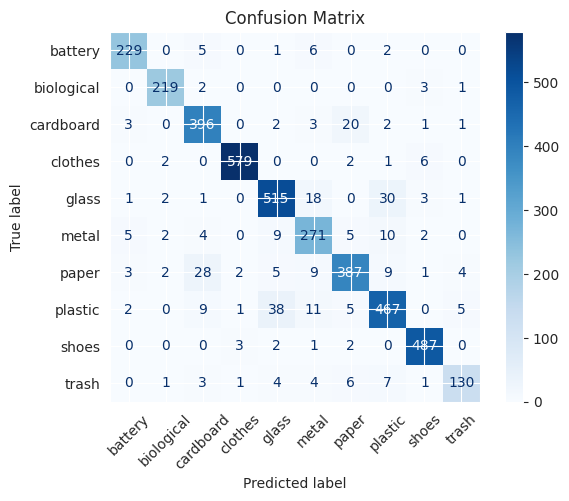

In [22]:
# Prediksi
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

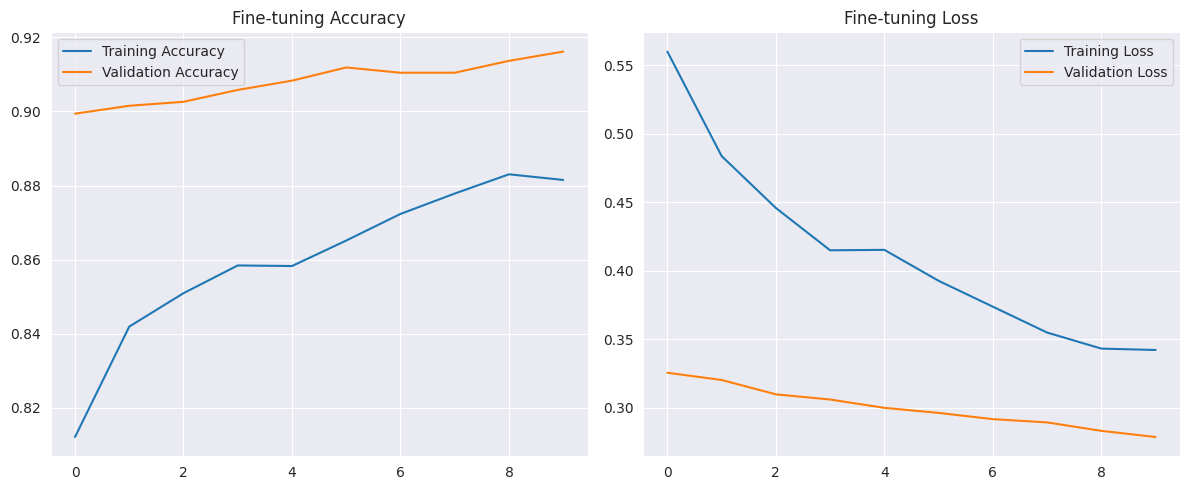

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot Akurasi
axs[0].plot(history_finetune.history['accuracy'], label='Training Accuracy')
axs[0].plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
axs[0].set_title('Fine-tuning Accuracy')
axs[0].legend()

# Plot Loss
axs[1].plot(history_finetune.history['loss'], label='Training Loss')
axs[1].plot(history_finetune.history['val_loss'], label='Validation Loss')
axs[1].set_title('Fine-tuning Loss')
axs[1].legend()

plt.tight_layout()
plt.show()


4005/4005 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step


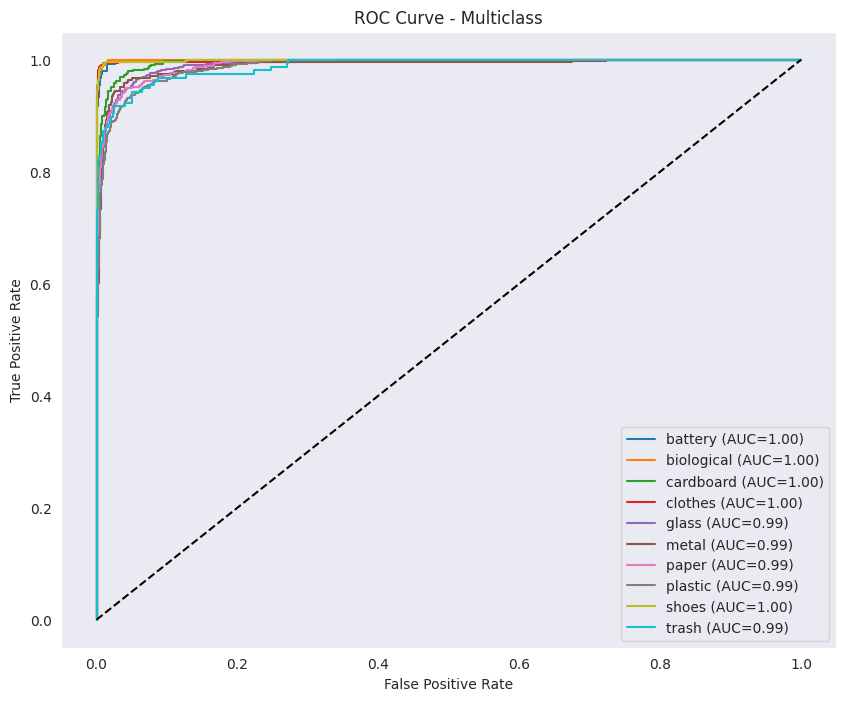

In [47]:
NUM_CLASSES = len(CLASSES)

# pastikan probabilitas
y_pred = model.predict(test_gen)

# pastikan label
y_true = test_gen.classes

y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASSES[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - nah Multiclass")
plt.legend()
plt.grid()
plt.show()